**Import libraries**

In [1]:
from IPython import get_ipython
from IPython.display import display
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
import traceback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau # Import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import itertools
from IPython import get_ipython
from IPython.display import display
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Path to data**

In [2]:
base_dir = "/content/drive/MyDrive/fieldimages"
train_dir = os.path.join(base_dir, "training")
test_dir = os.path.join(base_dir, "testing")
print("Train Dir Exists:", os.path.exists(train_dir))
print("Test Dir Exists:", os.path.exists(test_dir))

Train Dir Exists: True
Test Dir Exists: True


**input size**

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

**Training and validation data**

In [4]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)



Found 6247 images belonging to 3 classes.
Found 1561 images belonging to 3 classes.


**Testing data**

In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1200 images belonging to 3 classes.


**Get class indices**

In [6]:
class_labels = list(train_generator.class_indices.keys())
print("Class labels:", class_labels)

Class labels: ['citrus canker', 'health', 'melanose']


**Build the Model and add to layer**

In [7]:
def create_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    output_layer = Dense(len(class_labels), activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output_layer)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model
model = create_model()
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 56, 56, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 56, 56, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 56, 56, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 7,563,843 (28.85 MB)

 Trainable params: 526,339 (2.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

**Callbacks & Early Stopping**

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True)

**Converts an ImageDataGenerator to a tf.data.Dataset.**

In [9]:
def convert_to_tf_dataset(image_data_generator):
    return tf.data.Dataset.from_generator(
        lambda: image_data_generator,
        output_types=(tf.float32, tf.float32),
        output_shapes=(
            tf.TensorShape([None, IMG_SIZE[0], IMG_SIZE[1], 3]),
            tf.TensorShape([None, len(class_labels)]),
        ),
    ).prefetch(tf.data.AUTOTUNE)  # Prefetch for performance

# Convert your generators to tf.data.Datasets
train_dataset = convert_to_tf_dataset(train_generator)
val_dataset = convert_to_tf_dataset(val_generator)
total_train_samples = train_generator.samples
steps_per_epoch = max(196, int(total_train_samples / BATCH_SIZE))
total_val_samples = val_generator.samples
test_dataset = convert_to_tf_dataset(test_generator)
validation_steps = int(total_val_samples / BATCH_SIZE)

**Training Model**

In [10]:
istory = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,  # Add this line
    callbacks=[early_stop, reduce_lr, model_checkpoint]
)

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 2907s 15s/step - accuracy: 0.8789 - loss: 0.3216 - val_accuracy: 0.9368 - val_loss: 0.1834 - learning_rate: 0.0010
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 546s 3s/step - accuracy: 0.9629 - loss: 0.1035 - val_accuracy: 0.9673 - val_loss: 0.0997 - learning_rate: 0.0010
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 537s 3s/step - accuracy: 0.9718 - loss: 0.0838 - val_accuracy: 0.9640 - val_loss: 0.1073 - learning_rate: 0.0010
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 514s 3s/step - accuracy: 0.9782 - loss: 0.0643 - val_accuracy: 0.9765 - val_loss: 0.0756 - learning_rate: 0.0010
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 512s 3s/step - accuracy: 0.9761 - loss: 0.0567 - val_accuracy: 0.8940 - val_loss: 0.3224 - learning_rate: 0.0010
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.9753 - loss: 0.0695 - val_accuracy: 0.9699 - val_loss: 0.0899 - learning_rate: 0.0010
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 502s 3s/step - accuracy: 0.9859 - loss: 

**Plot Training Results**

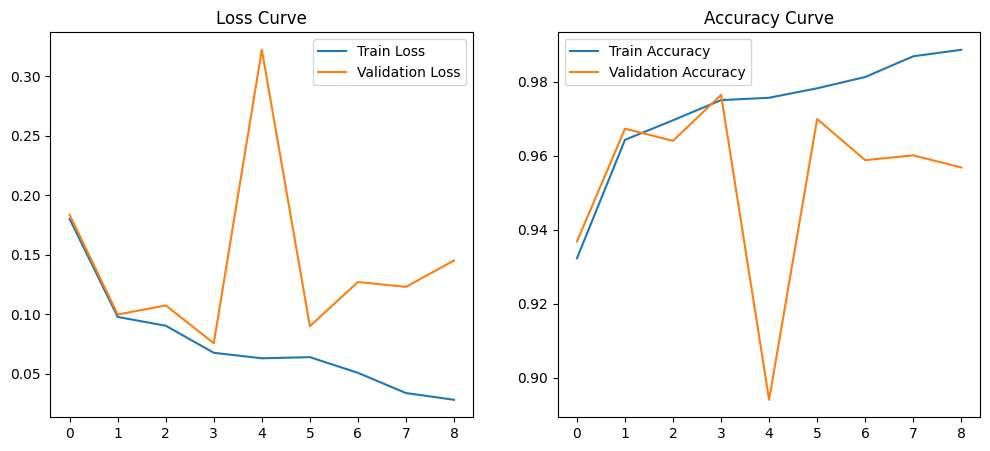

In [16]:
def plot_istory(history):
    plt.figure(figsize=(12, 5))

     # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.title("Accuracy Curve")

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title("Loss Curve")


    plt.show()

plot_istory(istory)

**Model Testing**

In [12]:
total_test_samples = test_generator.samples
test_steps = int(np.ceil(total_test_samples / BATCH_SIZE))

loss, accuracy = model.evaluate(test_dataset, steps=test_steps)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 486s 13s/step - accuracy: 0.9156 - loss: 0.2175
Test Loss: 0.1949511021375656
Test Accuracy: 0.934166669845581


**Generate the confusion matrix**

38/38 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step


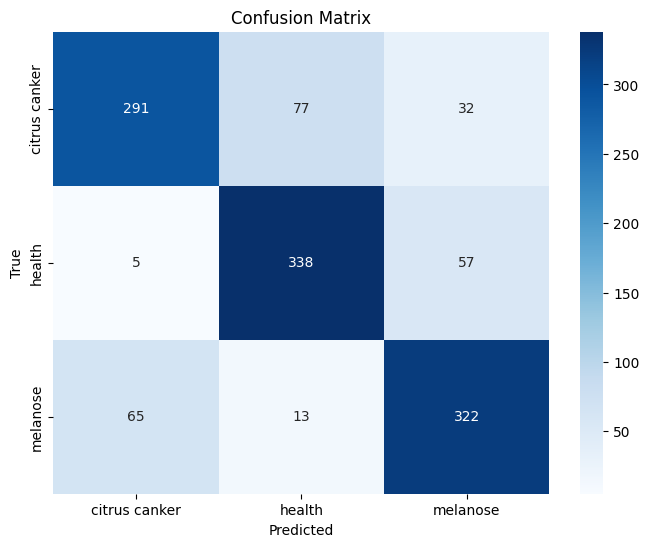

In [18]:
# Get the true labels from the test generator
y_true = test_generator.classes

# Get the predicted labels
y_pred = model.predict(test_dataset, steps=test_steps)
y_pred = np.argmax(y_pred, axis=1)  # Get the class with the highest probability

# Now you can create the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**Test Model on a Single Image**

Loading image: /content/drive/MyDrive/fieldimages/testing/health/H (352).jpg
Making prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Generating plot...


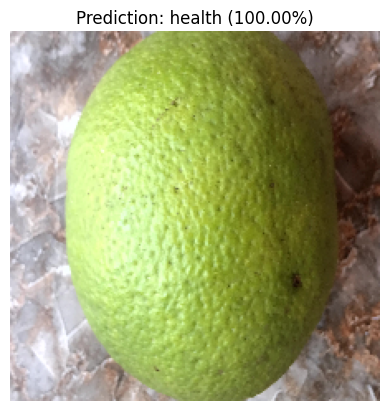

Plot displayed.


In [19]:
def predict_image(image_path='/content/drive/MyDrive/fieldimages/testing/health/H (352).jpg'):
    from tensorflow.keras.preprocessing import image
    import numpy as np

    try:
        print("Loading image:", image_path)
        img = image.load_img(image_path, target_size=IMG_SIZE)
        img_array = image.img_to_array(img) / 255.0  # Normalize
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        print("Making prediction...")
        prediction = model.predict(img_array)
        predicted_class = class_labels[np.argmax(prediction)]
        confidence = np.max(prediction)

        print("Generating plot...")
        plt.imshow(img)
        plt.title(f"Prediction: {predicted_class} ({confidence*100:.2f}%)")
        plt.axis("off")
        plt.show()  # Display the plot
        print("Plot displayed.")
    except Exception as e:
        print("An error occurred:", e)
        traceback.print_exc()

predict_image()

**Save Final Model**

In [20]:
model.save('orange_disease_model.keras')
print("Model saved as orange_disease_model.keras")

Model saved as orange_disease_model.keras
